重新做一个非常粗糙的场下+场上 场下数据的模型对比 用RF

目的是为了证明off-court 会增加预测水准 R^2增高了很多 正在的场上baseline还是原来的74%

但是要删除award 和injury 因为会有leak 而且目标要改成log_salary

In [48]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 可选：XGBoost & LightGBM，不装的话会自动跳过
try:
    from xgboost import XGBRegressor
except ImportError:
    XGBRegressor = None

try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

# 读 CSV（按你项目结构改一下路径）
DATA_PATH = Path("../data/processed/training_level1_full.csv")
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
df.head()




Shape: (2082, 132)


,player_id,season,salary_usd,log_salary,salary_cap,salary_cap_ratio,log_salary_cap_ratio,salary_cap_equiv,Age,GP,...,award_NBA Eastern Conference Finals MVP,award_NBA Western Conference Finals MVP,award_Rookie of the Year,award_Sixth Man of the Year,award_Twyman-Stokes Teammate of the Year Award,award_total,injury_events,injury_unique_dates,injury_unique_categories,injury_any
0,1,2020,43006362.0,17.576859,109140000.0,0.394048,0.332212,5.539837e+07,33,63,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,2,2020,28751775.0,17.174210,109140000.0,0.263439,0.233838,3.703642e+07,28,60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,3,2020,31626953.0,17.269520,109140000.0,0.289783,0.254474,4.074006e+07,30,67,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0
3,4,2020,29542010.0,17.201324,109140000.0,0.270680,0.239552,3.805435e+07,27,51,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,5,2020,27528090.0,17.130718,109140000.0,0.252227,0.224924,3.546013e+07,26,61,...,0.0,0.0,0.0,0.0,0.0,4.0,2.0,2.0,1.0,True


In [49]:
LEAKY_PREFIXES = ("award_", "injury_")

# ID 列 & 目标列
ID_COLS = ["player_id", "season"]
# TARGET_COL = "log_salary_cap_ratio"
TARGET_COL = "log_salary"

assert TARGET_COL in df.columns, "log_salary_cap_ratio 不在 df 里，请检查 pipeline"

# 绝对不能进特征的“目标相关列”（泄露风险）
TARGET_LEAK_BASE = [
    "salary_usd",
    "log_salary",
    "salary_cap",
    "salary_cap_ratio",
    "log_salary_cap_ratio",
    "salary_cap_equiv",
]
# 除了真正的 TARGET 本身
TARGET_LEAK_COLS = [c for c in TARGET_LEAK_BASE if c != TARGET_COL]

# 纯文本 / ID 类列（不用来训练）
TEXT_OR_ID_COLS = [
    "Player",          # 如果有
    "player_name",     # 如果有
    "team_abbr",
    "city",
    "state",
    "region",
    "agent_name",
    "agent_name_all",
]

# 先得到“候选特征列”
candidate_feature_cols = [
    c for c in df.columns
    if c not in ID_COLS + [TARGET_COL] + TARGET_LEAK_COLS + TEXT_OR_ID_COLS
]

# 只保留数值 / bool 类型
numeric_bool_cols = df[candidate_feature_cols].select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("候选特征（数值+bool）个数:", len(numeric_bool_cols))
print("前 15 个:", numeric_bool_cols[:15])




候选特征（数值+bool）个数: 115
前 15 个: ['Age', 'GP', 'W', 'L', 'Min', 'PTS', 'FGM', 'FGA', 'FG%', '3PM', '3PA', '3P%', 'FTM', 'FTA', 'FT%']


In [50]:
# ===============================
# 1) 先识别：off-court 全集（不做信息控制）
# ===============================
OFFCOURT_PREFIXES_ALL = (
    "draft_",
    "award_",
    "injury_",
    "agent_",
    "team_",
)

OFFCOURT_CONTAINS = (
    "team",
    "market",
    "city",
    "state",
    "region",
    "pick",   # overall_pick / round_pick
)

OFFCOURT_EXACT = [
    "Age",
    "age_now",
    "years_since_draft",
    "overall_pick",
    "round",
    "round_pick",
    "draft_year",
    "undrafted_flag",
]

offcourt_all = []
for c in numeric_bool_cols:
    lc = c.lower()
    if c.startswith(OFFCOURT_PREFIXES_ALL):
        offcourt_all.append(c)
    elif any(key in lc for key in OFFCOURT_CONTAINS):
        offcourt_all.append(c)
    elif c in OFFCOURT_EXACT:
        offcourt_all.append(c)

offcourt_all = sorted(set(offcourt_all))

# ===============================
# 2) 定义信息条件：CORE / FULL
# ===============================
LEAKY_PREFIXES = ("award_", "injury_")

OFFCOURT_CORE = [c for c in offcourt_all if not c.startswith(LEAKY_PREFIXES)]
OFFCOURT_FULL = offcourt_all.copy()

# ✅ 你现在这次实验用哪个？（主线用 CORE）
offcourt_cols = OFFCOURT_CORE
# offcourt_cols = OFFCOURT_FULL  # 以后做 ablation 再打开

# ===============================
# 3) 关键修复：oncourt_cols 也要剔除 leaky（否则会被归类到 on-court）
# ===============================
oncourt_cols = sorted([
    c for c in numeric_bool_cols
    if (c not in offcourt_all) and (not c.startswith(LEAKY_PREFIXES))
])

# ===============================
# 4) Sanity checks（必须 PASS）
# ===============================
print(f"On-court cols      : {len(oncourt_cols)}")
print(f"Off-court CORE     : {len(OFFCOURT_CORE)}")
print(f"Off-court FULL     : {len(OFFCOURT_FULL)}")

print("\nRemoved from CORE:")
print(sorted(set(OFFCOURT_FULL) - set(OFFCOURT_CORE)))

print("\nAward in ON-court? ", [c for c in oncourt_cols if c.startswith("award_")][:5])
print("Injury in ON-court? ", [c for c in oncourt_cols if c.startswith("injury_")][:5])

print("\nAward in OFF-court? ", [c for c in offcourt_cols if c.startswith("award_")][:5])
print("Injury in OFF-court? ", [c for c in offcourt_cols if c.startswith("injury_")][:5])

print("\nSample on-court cols:", oncourt_cols[:])
print("\nSample off-court cols:", offcourt_cols[:])



On-court cols      : 81
Off-court CORE     : 13
Off-court FULL     : 34

Removed from CORE:
['award_All-Defensive', 'award_All-NBA', 'award_All-Rookie', 'award_All-Star MVP', 'award_Clutch Player of the Year', 'award_Coach of the Year', 'award_Defensive Player of the Year', 'award_Finals MVP', 'award_Most Improved Player', 'award_Most Valuable Player', 'award_NBA Cup All-Tournament Team', 'award_NBA Cup MVP', 'award_NBA Eastern Conference Finals MVP', 'award_NBA Western Conference Finals MVP', 'award_Rookie of the Year', 'award_Sixth Man of the Year', 'award_Twyman-Stokes Teammate of the Year Award', 'award_total', 'injury_events', 'injury_unique_categories', 'injury_unique_dates']

Award in ON-court?  []
Injury in ON-court?  []

Award in OFF-court?  []
Injury in OFF-court?  []

Sample on-court cols: ['+/-', '3P%', '3PA', '3PA_per_gp', '3PA_per_min', '3PM', '3PM_per_gp', '3PM_per_min', 'AST', 'AST_TO_ratio', 'AST_per_gp', 'AST_per_min', 'BLK', 'BLK_per_gp', 'BLK_per_min', 'DD2', 'DREB'

In [51]:
print("Seasons:", sorted(df["season"].unique()))

# 2020–2023 作为训练，2024 作为测试
train_df = df[df["season"] < 2024].copy()
test_df  = df[df["season"] == 2024].copy()

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

# 填缺失
train_df = train_df.fillna(0)
test_df  = test_df.fillna(0)

y_train = train_df[TARGET_COL].values
y_test  = test_df[TARGET_COL].values

# Level0: on-court only
X_train_0 = train_df[oncourt_cols].values
X_test_0  = test_df[oncourt_cols].values

# Level1: on + off
feature_cols_1 = oncourt_cols + offcourt_cols
X_train_1 = train_df[feature_cols_1].values
X_test_1  = test_df[feature_cols_1].values


Seasons: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Train shape: (1659, 132)
Test shape : (423, 132)


In [52]:
def evaluate_regression(y_true, y_pred, name="model"):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)       # 不用 squared=False，兼容旧版本 sklearn
    r2 = r2_score(y_true, y_pred)
    # MAPE 会很大，仅作参考
    mape = np.mean(np.abs((y_true - y_pred) / y_true))

    print(f"=== {name} ===")
    print(f"MAE  : {mae:,.4f}")
    print(f"RMSE : {rmse:,.4f}")
    print(f"R^2  : {r2:.4f}")
    print(f"MAPE : {mape*100:.2f}%")
    return {"mae": mae, "rmse": rmse, "r2": r2, "mape": mape}



In [53]:
def run_models_for_level(level_name, X_train, X_test, y_train, y_test):
    results = []

    
    # 1) Ridge：加 StandardScaler，正则稍微大一点
    ridge = make_pipeline(
        StandardScaler(),
        Ridge(alpha=10.0)
    )
    ridge.fit(X_train, y_train)
    y_tr = ridge.predict(X_train)
    y_te = ridge.predict(X_test)
    metrics_tr = evaluate_regression(y_train, y_tr, name=f"{level_name}-Ridge-Train")
    metrics_te = evaluate_regression(y_test, y_te, name=f"{level_name}-Ridge-Test")
    results.append({"level": level_name, "model": "Ridge", "split": "train", **metrics_tr})
    results.append({"level": level_name, "model": "Ridge", "split": "test",  **metrics_te})

    print("\n" + "-"*60 + "\n")

    # 2) RandomForest
    rf = RandomForestRegressor(
        n_estimators=500,
        max_depth=20,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    )
    rf.fit(X_train, y_train)
    y_tr = rf.predict(X_train)
    y_te = rf.predict(X_test)
    metrics_tr = evaluate_regression(y_train, y_tr, name=f"{level_name}-RF-Train")
    metrics_te = evaluate_regression(y_test, y_te, name=f"{level_name}-RF-Test")
    results.append({
        "level": level_name,
        "model": "RandomForest",
        "split": "train", **metrics_tr,
    })
    results.append({
        "level": level_name,
        "model": "RandomForest",
        "split": "test", **metrics_te,
    })

    print("\n" + "-"*60 + "\n")

    # 3) XGBoost（如果装了）
    if XGBRegressor is not None:
        xgb = XGBRegressor(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            n_jobs=-1,
            random_state=42,
        )
        xgb.fit(X_train, y_train)
        y_tr = xgb.predict(X_train)
        y_te = xgb.predict(X_test)
        metrics_tr = evaluate_regression(y_train, y_tr, name=f"{level_name}-XGB-Train")
        metrics_te = evaluate_regression(y_test, y_te, name=f"{level_name}-XGB-Test")
        results.append({
            "level": level_name,
            "model": "XGB",
            "split": "train", **metrics_tr,
        })
        results.append({
            "level": level_name,
            "model": "XGB",
            "split": "test", **metrics_te,
        })

        print("\n" + "-"*60 + "\n")
    else:
        print(f"⚠ XGBoost not installed, skipping for {level_name}")

    # 4) LightGBM（如果装了）
    if LGBMRegressor is not None:
        lgbm = LGBMRegressor(
            n_estimators=600,
            learning_rate=0.05,
            max_depth=-1,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="regression",
            random_state=42,
            n_jobs=-1,
        )
        lgbm.fit(X_train, y_train)
        y_tr = lgbm.predict(X_train)
        y_te = lgbm.predict(X_test)
        metrics_tr = evaluate_regression(y_train, y_tr, name=f"{level_name}-LGBM-Train")
        metrics_te = evaluate_regression(y_test, y_te, name=f"{level_name}-LGBM-Test")
        results.append({
            "level": level_name,
            "model": "LGBM",
            "split": "train", **metrics_tr,
        })
        results.append({
            "level": level_name,
            "model": "LGBM",
            "split": "test", **metrics_te,
        })
    else:
        print(f"⚠ LightGBM not installed, skipping for {level_name}")

    return results




In [54]:
all_results = []

print("====== Level0: on-court only ======")
res0 = run_models_for_level("Level0_oncourt", X_train_0, X_test_0, y_train, y_test)
all_results.extend(res0)

print("\n\n====== Level1: on + off-court ======")
res1 = run_models_for_level("Level1_on_off", X_train_1, X_test_1, y_train, y_test)
all_results.extend(res1)

results_df = pd.DataFrame(all_results)
results_df


====== Level0: on-court only ======
=== Level0_oncourt-Ridge-Train ===
MAE  : 0.6511
RMSE : 0.8612
R^2  : 0.5016
MAPE : 4.37%
=== Level0_oncourt-Ridge-Test ===
MAE  : 0.6988
RMSE : 0.8714
R^2  : 0.4374
MAPE : 4.46%

------------------------------------------------------------

=== Level0_oncourt-RF-Train ===
MAE  : 0.4228
RMSE : 0.5886
R^2  : 0.7672
MAPE : 2.86%
=== Level0_oncourt-RF-Test ===
MAE  : 0.6971
RMSE : 0.8590
R^2  : 0.4533
MAPE : 4.46%

------------------------------------------------------------

=== Level0_oncourt-XGB-Train ===
MAE  : 0.0179
RMSE : 0.0244
R^2  : 0.9996
MAPE : 0.12%
=== Level0_oncourt-XGB-Test ===
MAE  : 0.7070
RMSE : 0.8822
R^2  : 0.4233
MAPE : 4.53%

------------------------------------------------------------

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001649 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 14267
[LightGBM] [Info] Number of data points in the trai

c:\Users\Junha\miniconda3\envs\nba-research\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Junha\miniconda3\envs\nba-research\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


=== Level0_oncourt-LGBM-Train ===
MAE  : 0.0457
RMSE : 0.0831
R^2  : 0.9954
MAPE : 0.31%
=== Level0_oncourt-LGBM-Test ===
MAE  : 0.7223
RMSE : 0.9069
R^2  : 0.3906
MAPE : 4.64%


====== Level1: on + off-court ======
=== Level1_on_off-Ridge-Train ===
MAE  : 0.5802
RMSE : 0.7831
R^2  : 0.5879
MAPE : 3.91%
=== Level1_on_off-Ridge-Test ===
MAE  : 0.6084
RMSE : 0.7789
R^2  : 0.5505
MAPE : 3.95%

------------------------------------------------------------

=== Level1_on_off-RF-Train ===
MAE  : 0.3495
RMSE : 0.5249
R^2  : 0.8149
MAPE : 2.39%
=== Level1_on_off-RF-Test ===
MAE  : 0.5628
RMSE : 0.7264
R^2  : 0.6091
MAPE : 3.61%

------------------------------------------------------------

=== Level1_on_off-XGB-Train ===
MAE  : 0.0091
RMSE : 0.0127
R^2  : 0.9999
MAPE : 0.06%
=== Level1_on_off-XGB-Test ===
MAE  : 0.4446
RMSE : 0.6198
R^2  : 0.7154
MAPE : 2.89%

------------------------------------------------------------

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of 

c:\Users\Junha\miniconda3\envs\nba-research\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Junha\miniconda3\envs\nba-research\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,level,model,split,mae,rmse,r2,mape
0,Level0_oncourt,Ridge,train,0.651105,0.861167,0.501639,0.043734
1,Level0_oncourt,Ridge,test,0.698760,0.871353,0.437437,0.044633
2,Level0_oncourt,RandomForest,train,0.422843,0.588583,0.767199,0.028551
3,Level0_oncourt,RandomForest,test,0.697111,0.858989,0.453288,0.044600
4,Level0_oncourt,XGB,train,0.017940,0.024440,0.999599,0.001181
5,Level0_oncourt,XGB,test,0.706951,0.882239,0.423293,0.045280
6,Level0_oncourt,LGBM,train,0.045704,0.083080,0.995362,0.003114
7,Level0_oncourt,LGBM,test,0.722348,0.906926,0.390565,0.046380
8,Level1_on_off,Ridge,train,0.580218,0.783082,0.587919,0.039112
9,Level1_on_off,Ridge,test,0.608430,0.778871,0.550516,0.039466


In [55]:
# paper ready cell

# ===== Paper-ready main results (TEST ONLY) =====
paper_models = ["Ridge", "RandomForest"]

paper_table = (
    results_df
    .query("split == 'test' and model in @paper_models")
    .loc[:, ["level", "model", "mae", "rmse", "r2"]]
    .sort_values(["level", "model"])
    .reset_index(drop=True)
)
paper_table["level"] = paper_table["level"].map({
    "Level0_oncourt": "L0′ (On-court)",
    "Level1_on_off": "L1-A (On + Off)"
})

level_order = ["L0′ (On-court)", "L1-A (On + Off)"]
model_order = ["Ridge", "RandomForest"]

paper_table["level"] = pd.Categorical(
    paper_table["level"],
    categories=level_order,
    ordered=True
)

paper_table["model"] = pd.Categorical(
    paper_table["model"],
    categories=model_order,
    ordered=True
)

def get_r2(level, model):
    return paper_table.query(
        "level == @level and model == @model"
    )["r2"].values[0]

delta_rf = get_r2("L1-A (On + Off)", "RandomForest") - get_r2("L0′ (On-court)", "RandomForest")
delta_ridge = get_r2("L1-A (On + Off)", "Ridge") - get_r2("L0′ (On-court)", "Ridge")

print(f"ΔR² (RF, L1-A − L0′): {delta_rf:.3f}")
print(f"ΔR² (Ridge, L1-A − L0′): {delta_ridge:.3f}")
paper_table

ΔR² (RF, L1-A − L0′): 0.156
ΔR² (Ridge, L1-A − L0′): 0.113


,level,model,mae,rmse,r2
0,L0′ (On-court),RandomForest,0.697111,0.858989,0.453288
1,L0′ (On-court),Ridge,0.698760,0.871353,0.437437
2,L1-A (On + Off),RandomForest,0.562763,0.726385,0.609054
3,L1-A (On + Off),Ridge,0.608430,0.778871,0.550516


In [56]:
# Level1: on-court + off-court 全部
feature_cols_1 = oncourt_cols + offcourt_cols

X_train_1 = train_df[feature_cols_1].values
X_test_1  = test_df[feature_cols_1].values

rf1 = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    n_jobs=-1,
    random_state=42,
)

rf1.fit(X_train_1, y_train)

y_pred_train_1 = rf1.predict(X_train_1)
y_pred_test_1  = rf1.predict(X_test_1)

print("Train performance (Level1 / on+off)")
metrics_train_1 = evaluate_regression(y_train, y_pred_train_1, name="Level1-Train")

print("\nTest performance (Level1 / on+off)")
metrics_test_1 = evaluate_regression(y_test, y_pred_test_1, name="Level1-Test")


Train performance (Level1 / on+off)
=== Level1-Train ===
MAE  : 0.1736
RMSE : 0.2724
R^2  : 0.9501
MAPE : 1.18%

Test performance (Level1 / on+off)
=== Level1-Test ===
MAE  : 0.4801
RMSE : 0.6545
R^2  : 0.6826
MAPE : 3.10%


In [57]:
results_df[(results_df["split"]=="test")].sort_values(["level","model"])
results_df

,level,model,split,mae,rmse,r2,mape
0,Level0_oncourt,Ridge,train,0.651105,0.861167,0.501639,0.043734
1,Level0_oncourt,Ridge,test,0.698760,0.871353,0.437437,0.044633
2,Level0_oncourt,RandomForest,train,0.422843,0.588583,0.767199,0.028551
3,Level0_oncourt,RandomForest,test,0.697111,0.858989,0.453288,0.044600
4,Level0_oncourt,XGB,train,0.017940,0.024440,0.999599,0.001181
5,Level0_oncourt,XGB,test,0.706951,0.882239,0.423293,0.045280
6,Level0_oncourt,LGBM,train,0.045704,0.083080,0.995362,0.003114
7,Level0_oncourt,LGBM,test,0.722348,0.906926,0.390565,0.046380
8,Level1_on_off,Ridge,train,0.580218,0.783082,0.587919,0.039112
9,Level1_on_off,Ridge,test,0.608430,0.778871,0.550516,0.039466


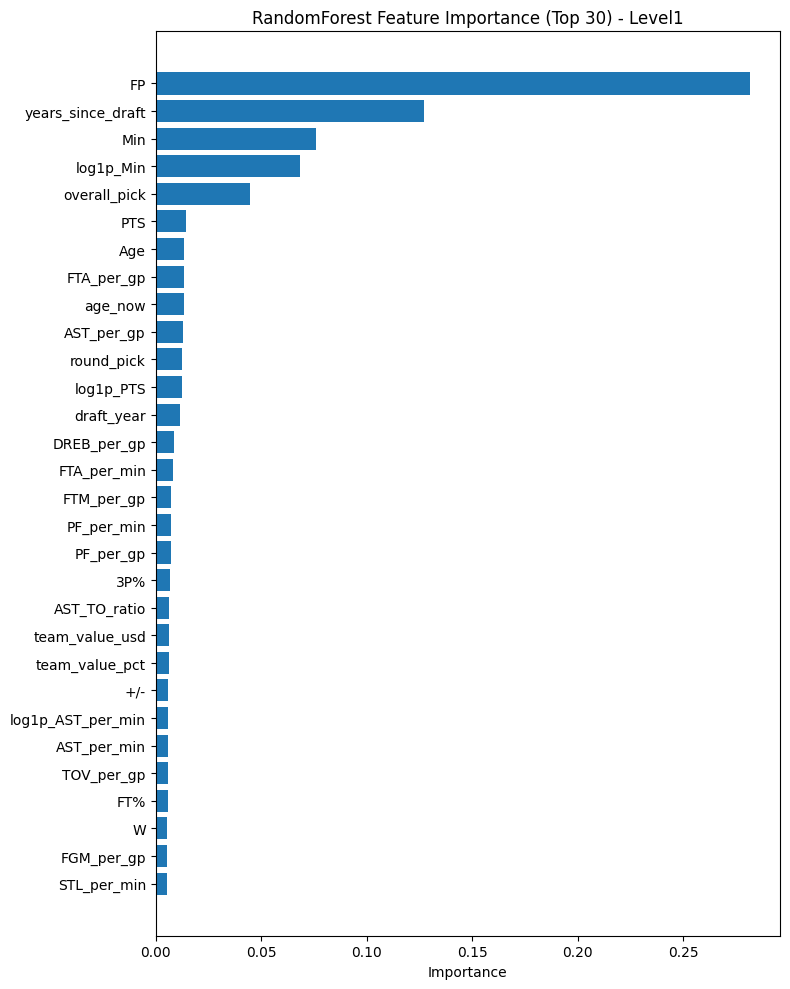

Off-court features in top-30: 8 / 30


,feature,importance,is_offcourt
53,STL_per_min,0.005349,False
25,FGM_per_gp,0.005447,False
59,W,0.005533,False
28,FT%,0.005634,False
56,TOV_per_gp,0.005653,False
11,AST_per_min,0.005665,False
64,log1p_AST_per_min,0.005685,False
0,+/-,0.005953,False
90,team_value_pct,0.006083,True
91,team_value_usd,0.006251,True


In [58]:
#  看level1 特征重要性
importances = rf1.feature_importances_
feat_imp = pd.DataFrame({
    "feature": feature_cols_1,
    "importance": importances,
})

feat_imp["is_offcourt"] = feat_imp["feature"].isin(offcourt_cols)
feat_imp = feat_imp.sort_values("importance", ascending=False)

top_k = 30
top = feat_imp.head(top_k).sort_values("importance")

plt.figure(figsize=(8, 10))
plt.barh(top["feature"], top["importance"])
plt.title(f"RandomForest Feature Importance (Top {top_k}) - Level1")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print("Off-court features in top-30:", top["is_offcourt"].sum(), "/", top_k)
top.head(10)
